In [2]:
#Step 1: Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_california_housing


import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [3]:
#Step 2: Load Dataset
# Load dataset
dataset = fetch_california_housing()
#df = pd.read_csv("1_boston_housing.csv")
#X = df.drop("MEDV", axis=1)   # Features
#y = df["MEDV"]                # Target
df = pd.DataFrame(dataset.data, columns=dataset.feature_names)

# Remove quotes from column names (important for your dataset)
df.columns = df.columns.str.replace('"', '')

# Display first 5 rows
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [4]:
#Step 3: Split Features and Target
X = df  # Features
y = dataset.target              # Target

print(X.shape, y.shape)

(20640, 8) (20640,)


In [5]:
#Step 4: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
#Step 5: Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
model = Sequential()
model.add(Dense(1, input_shape=(X_train.shape[1],), activation='linear'))

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

history = model.fit(
    X_train, y_train,
    epochs=25,
    validation_split=0.05,
    verbose=1
)

Epoch 1/25
491/491 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 6.8310 - mae: 2.0119 - val_loss: 5.0829 - val_mae: 1.7524
Epoch 2/25
491/491 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 3.9662 - mae: 1.4991 - val_loss: 3.0377 - val_mae: 1.3263
Epoch 3/25
491/491 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 2.4106 - mae: 1.1216 - val_loss: 1.8675 - val_mae: 1.0059
Epoch 4/25
491/491 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.5358 - mae: 0.8430 - val_loss: 1.2207 - val_mae: 0.7758
Epoch 5/25
491/491 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.0734 - mae: 0.6712 - val_loss: 0.8913 - val_mae: 0.6454
Epoch 6/25
491/491 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.8489 - mae: 0.5903 - val_loss: 0.7422 - val_mae: 0.5950
Epoch 7/25
491/491 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.7451 - mae: 0.5632 - val_loss: 0.6765 - val_mae: 0.5791
Epoch 8/25
491/491 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6927 - mae: 0.5550 - val_loss: 0.6466 - val_mae: 0.5721
Epoch 9/25
491/491 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - l

In [10]:
#Step 8: Evaluate Model
loss, mae = model.evaluate(X_test, y_test)

print("Test Loss (MSE):", loss)
print("Test MAE:", mae)

129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 9.5256 - mae: 2.3924
Test Loss (MSE): 9.525593757629395
Test MAE: 2.392378330230713


In [12]:
#Step 9: Predictions
y_pred = model.predict(X_test)

# Compare actual vs predicted
for i in range(5):
    print(f"Actual: {y_test[i]:.2f} | Predicted: {y_pred[i][0]:.2f}")

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Actual: 0.48 | Predicted: 0.48
Actual: 0.46 | Predicted: 0.39
Actual: 5.00 | Predicted: 1.19
Actual: 2.19 | Predicted: -1.19
Actual: 2.78 | Predicted: 0.74


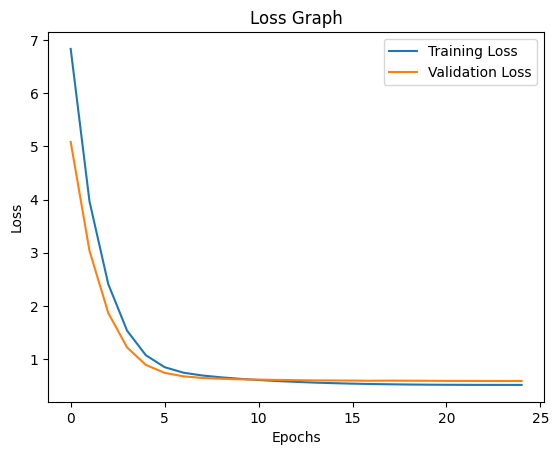

In [13]:
#Step 10: Plot Training Graphs
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Graph")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()